# 선형 회귀(Linear Regression) 강의 자료

> 머신러닝 입문 — 가장 기본이 되는 회귀 모델을 두 개의 실제 데이터셋으로 학습한다.

## 학습 목표
1. 머신러닝(ML)의 큰 그림과 **회귀(Regression)** 의 위치를 이해한다.
2. **선형 회귀**의 원리(직선 긋기, 비용 최소화)를 직관적으로 안다.
3. **재사용 가능한 전처리 루틴**을 만든다 — 결측치가 없어도 습관처럼 갖춰 둔다.
4. `scikit-learn` 으로 학습 → 예측 → 평가(MAE/RMSE/R²)까지 전체 흐름을 익힌다.

## 사용 데이터
| 데이터 | 크기 | 특징 | 타깃 |
|--------|------|------|------|
| `california_housing_test.csv` | 3000 × 9 | 전부 수치형 → **스케일링** 중심 | `median_house_value` (집값) |
| `computer_prices_all.csv` | 100000 × 33 | 범주형 다수 → **인코딩** 중심 | `price` (가격) |


## 1. 머신러닝(ML)이란?

### 한 줄 정의
**데이터로부터 규칙(패턴)을 스스로 찾아내, 새로운 데이터의 결과를 예측하는 기술.**

### 직관적 설명
사람이 `if-else` 규칙을 일일이 코딩하는 대신, **데이터(문제+정답)를 잔뜩 보여주고 모델이 규칙을 알아서 학습**하게 한다.
- 전통 프로그래밍: `규칙 + 입력 → 출력`
- 머신러닝: `입력 + 출력(정답) → 규칙(모델)` → 이후 새 입력에 규칙을 적용

### 지도학습 vs 비지도학습
| 구분 | 정답(label) | 예시 |
|------|:---:|------|
| **지도학습(Supervised)** | 있음 | 집값 예측, 스팸 분류 |
| 비지도학습(Unsupervised) | 없음 | 고객 군집화(클러스터링) |

### 지도학습: 회귀 vs 분류
| 구분 | 예측 대상 | 예시 | 대표 평가지표 |
|------|-----------|------|---------------|
| **회귀(Regression)** | **연속된 숫자** | 집값, 가격, 온도 | MAE, RMSE, R² |
| 분류(Classification) | **범주(카테고리)** | 합격/불합격, 개/고양이 | Accuracy, F1 |

> 이 강의의 **선형 회귀는 "지도학습 > 회귀"** 에 속한다. 타깃이 집값·가격처럼 연속된 숫자이기 때문이다.

### 📝 시험 출제 포인트
- "타깃이 연속형 숫자인가 / 범주인가" 로 **회귀 vs 분류**를 고르는 문제가 자주 나온다.
- 집값·가격·수요량 예측 → **회귀**.


## 2. 선형 회귀(Linear Regression)

### 한 줄 정의
**입력 특성들의 가중합으로 숫자를 예측하는, 가장 단순한 직선(평면) 모델.**

### 직관적 설명
점들이 흩어진 그래프에 **가장 잘 맞는 직선 하나를 긋는 것**이 선형 회귀다.
특성이 여러 개면 직선이 아니라 다차원 평면(초평면)이 된다.

예측식 (특성이 n개일 때):
$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

- `w` (가중치, coefficient): 각 특성이 결과에 미치는 영향력 (기울기)
- `b` (절편, intercept): 모든 특성이 0일 때의 기본값

### 어떻게 "가장 잘 맞는" 직선을 찾나?
**예측값과 실제값의 차이(오차)를 제곱해 더한 값(MSE)을 가장 작게** 만드는 `w`, `b` 를 찾는다.
이 오차를 줄이는 과정이 곧 "학습(fit)" 이다.

### 코드 예시 (개념 확인용 최소 코드)
```python
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[1], [2], [3], [4]])   # 특성
y = np.array([3, 5, 7, 9])           # 정답 (y = 2x + 1)

model = LinearRegression().fit(X, y)
print('기울기 w:', model.coef_)        # ≈ [2.]
print('절편 b:', model.intercept_)      # ≈ 1.0
print('예측:', model.predict([[5]]))    # ≈ [11.]
```

### 📝 시험 출제 포인트
- `LinearRegression()` → `.fit(X, y)` → `.predict(X_test)` 3단계 흐름.
- 학습된 `.coef_`(가중치), `.intercept_`(절편) 의 의미를 묻는 문제.
- 회귀 평가지표(MAE/MSE/RMSE/R²) 계산.

### ⚠️ 자주 하는 실수
- **타깃(y)을 특성(X)에 포함**시키는 실수 → 정답을 보고 정답을 맞히는 꼴(데이터 누설).
- **스케일링을 test까지 보고 fit** → `scaler.fit`은 **train 으로만**. test는 `transform`만.
- 분류 문제에 LinearRegression 사용 → 범주 예측은 `LogisticRegression`/분류 모델.

### 관련 개념
- 규제(Regularization): Ridge, Lasso — 과적합을 줄인 선형 회귀의 변형.


## 3. 전처리 루틴은 왜 "항상" 만드는가

> 이번 두 데이터는 결측치가 **0개**다. 그래도 전처리 루틴은 만든다. 이유:

1. **현업 데이터는 거의 항상 더럽다** — 결측치·범주형·이상치가 기본. 깨끗한 데이터는 예외다.
2. **재현성·재사용** — 같은 함수를 다른 데이터에도 그대로 적용 → 실수 감소.
3. **모델 요구사항** — 선형 회귀는 **숫자만** 받는다. 범주형(문자)은 반드시 숫자로 인코딩해야 한다.
4. **시험 대비** — 결측치 처리·인코딩·스케일링은 AICE 단골 출제 영역.

### 표준 전처리 순서
```
원본 → ① 불필요 컬럼 제거 → ② 결측치 처리 → ③ 범주형 인코딩
     → ④ train/test 분리 → ⑤ 스케일링(train으로만 fit)
```

> ④ 분리를 ⑤ 스케일링보다 **먼저** 하는 이유: test 정보가 train 전처리에 새어들지 않게 하기 위함(데이터 누설 방지).


In [1]:
# 공통 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
pd.set_option('display.max_columns', 40)
print('ready')

ready


In [3]:
def preprocess_features(df, target, drop_cols=None, high_card_threshold=50, verbose=True):
  """재사용 전처리 루틴 (결측치가 없어도 항상 동작).

  순서: 불필요 컬럼 제거 -> 결측치 처리(수치=중앙값, 범주=최빈값)
        -> 고카디널리티 범주형 제거 -> 원-핫 인코딩
  반환: (X 전처리된 특성 DataFrame, y 타깃 Series)
  """
  data = df.copy()
  drop_cols = drop_cols or []
  data = data.drop(columns=[col for col in drop_cols if col in data.columns])

  y = data[target]
  X = data.drop(columns=[target])

  # ① 결측치 리포트 (없어도 확인하는 습관)
  total_na = int(X.isnull().sum().sum())
  if verbose:
    print(f'[결측치] 총 {total_na}개 (없어도 처리 루틴은 그대로 실행)')

  # ② 결측치 처리: 수치형=중앙값, 범주형=최빈값
  num_cols = X.select_dtypes(include='number').columns
  cat_cols = X.select_dtypes(include='object').columns
  for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
  for col in cat_cols:
    fill = X[col].mode().iloc[0] if not X[col].mode().empty else 'NA'
    X[col] = X[col].fillna(fill)

  # ③ 고카디널리티 범주형 제거 (model 처럼 거의 고유한 식별자 컬럼)
  high_card = [col for col in cat_cols if X[col].nunique() > high_card_threshold]
  if high_card and verbose:
    print(f'[고카디널리티 제거] {high_card}')
  X = X.drop(columns=high_card)

  # ④ 원-핫 인코딩 (남은 범주형 -> 0/1 숫자)
  X = pd.get_dummies(X, drop_first=True)
  if verbose:
    print(f'[전처리 완료] X shape = {X.shape}')
  return X, y

## 4. 예제 1 — California Housing (전부 수치형)

캘리포니아 지역별 인구·소득·주택 정보로 **집값(`median_house_value`)** 을 예측한다.
모든 컬럼이 숫자라 인코딩은 필요 없고, **스케일링**이 핵심이다.


In [4]:
# 데이터 로드 & 탐색(EDA)
df_ca = pd.read_csv('pandas/data/california_housing_test.csv')
print('shape:', df_ca.shape)
display(df_ca.head())
print('\n[info]'); df_ca.info()
print('\n[결측치]\n', df_ca.isnull().sum())

shape: (3000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0



[info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB

[결측치]
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [5]:
# 기초 통계
display(df_ca.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [6]:
# 전처리 루틴 적용 (수치형뿐이라 인코딩 대상 없음)
X_ca, y_ca = preprocess_features(df_ca, target='median_house_value')
display(X_ca.head(3))

[결측치] 총 0개 (없어도 처리 루틴은 그대로 실행)
[전처리 완료] X shape = (3000, 8)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934


In [7]:
# train / test 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X_ca, y_ca, test_size=0.2, random_state=42)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (2400, 8)  test: (600, 8)


In [8]:
# 스케일링: train 으로만 fit, test 는 transform (누설 방지)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('스케일링 후 train 평균(거의 0):', X_train_s.mean(axis=0).round(2)[:4])

스케일링 후 train 평균(거의 0): [ 0. -0. -0. -0.]


In [9]:
# 모델 학습
model_ca = LinearRegression()
model_ca.fit(X_train_s, y_train)
print('학습 완료. 절편(intercept):', round(model_ca.intercept_, 2))

학습 완료. 절편(intercept): 207293.29


In [10]:
# 예측 & 평가
pred_ca = model_ca.predict(X_test_s)

mae = mean_absolute_error(y_test, pred_ca)
mse = mean_squared_error(y_test, pred_ca)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_ca)
print(f'MAE  = {mae:,.2f}')
print(f'MSE  = {mse:,.2f}')
print(f'RMSE = {rmse:,.2f}')
print(f'R^2  = {r2:.4f}   (1에 가까울수록 좋음)')

MAE  = 49,554.28
MSE  = 4,586,505,886.68
RMSE = 67,723.75
R^2  = 0.6358   (1에 가까울수록 좋음)


In [11]:
# 회귀계수 해석: 어떤 특성이 집값에 큰 영향?
coef_ca = pd.Series(model_ca.coef_, index=X_ca.columns).sort_values(key=abs, ascending=False)
print('영향력 큰 특성 (절댓값 기준):')
print(coef_ca.to_string())

영향력 큰 특성 (절댓값 기준):
latitude             -92208.298896
longitude            -88056.068687
median_income         72704.603850
population           -41314.086056
total_bedrooms        40575.512838
households            22118.176572
total_rooms          -16764.420391
housing_median_age    14438.454250


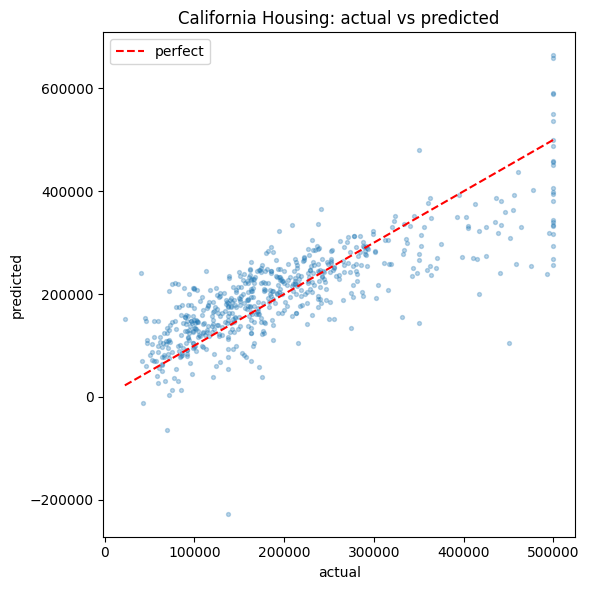

In [12]:
# 시각화: 실제값 vs 예측값 (대각선에 가까울수록 정확)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_ca, s=8, alpha=0.3)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', label='perfect')
plt.xlabel('actual'); plt.ylabel('predicted')
plt.title('California Housing: actual vs predicted')
plt.legend(); plt.tight_layout(); plt.show()

## 5. 예제 2 — Computer Prices (범주형 포함 → 인코딩)

컴퓨터 사양(CPU/GPU/RAM/화면 등)으로 **가격(`price`)** 을 예측한다.
`brand`, `os`, `cpu_brand` 같은 **문자형(범주형)** 컬럼이 많아 **원-핫 인코딩**이 핵심이다.
`model`(99,036종)·`cpu_model`(26,971종)은 거의 고유한 식별자라 전처리에서 자동 제거된다.


In [13]:
# 데이터 로드 & 탐색
df_pc = pd.read_csv('pandas/data/computer_prices_all.csv')
print('shape:', df_pc.shape)
display(df_pc.head(3))
print('[결측치 총합]', df_pc.isnull().sum().sum())

shape: (100000, 33)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99


[결측치 총합] 0


In [14]:
# 범주형 컬럼의 고유값 수 (고카디널리티 확인)
obj_cols = df_pc.select_dtypes('object').columns
print(df_pc[obj_cols].nunique().sort_values(ascending=False).to_string())

model           99036
cpu_model       26971
gpu_model          49
brand              10
form_factor        10
display_type        6
resolution          6
os                  4
gpu_brand           4
storage_type        4
wifi                4
cpu_brand           3
device_type         2


In [15]:
# 전처리 루틴 적용
#  - high_card_threshold=50 -> model(99036), cpu_model(26971) 자동 제거
#  - 나머지 범주형은 원-핫 인코딩
X_pc, y_pc = preprocess_features(df_pc, target='price', high_card_threshold=50)
print('인코딩 후 특성 수:', X_pc.shape[1])

[결측치] 총 0개 (없어도 처리 루틴은 그대로 실행)
[고카디널리티 제거] ['model', 'cpu_model']
[전처리 완료] X shape = (100000, 110)
인코딩 후 특성 수: 110


In [16]:
# 분리 -> 스케일링 -> 학습 -> 평가 (예제1과 동일 흐름)
Xtr, Xte, ytr, yte = train_test_split(X_pc, y_pc, test_size=0.2, random_state=42)

sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

model_pc = LinearRegression().fit(Xtr_s, ytr)
pred_pc = model_pc.predict(Xte_s)

print(f'MAE  = {mean_absolute_error(yte, pred_pc):,.2f}')
print(f'RMSE = {np.sqrt(mean_squared_error(yte, pred_pc)):,.2f}')
print(f'R^2  = {r2_score(yte, pred_pc):.4f}')

MAE  = 143.19
RMSE = 202.85
R^2  = 0.8754


In [17]:
# 가격에 영향 큰 특성 Top 10
coef_pc = pd.Series(model_pc.coef_, index=X_pc.columns).sort_values(key=abs, ascending=False)
print('가격 영향력 Top 10:')
print(coef_pc.head(10).to_string())

가격 영향력 Top 10:
gpu_brand_NVIDIA         -3.794502e+13
device_type_Laptop        3.291339e+13
gpu_brand_Intel          -3.109307e+13
form_factor_ATX           2.561103e+13
form_factor_Micro-ATX     1.983742e+13
gpu_brand_Apple          -1.894515e+13
form_factor_Full-Tower    1.816012e+13
form_factor_SFF           1.614325e+13
form_factor_Mini-ITX      1.238589e+13
gpu_model_Arc A580        7.324149e+12


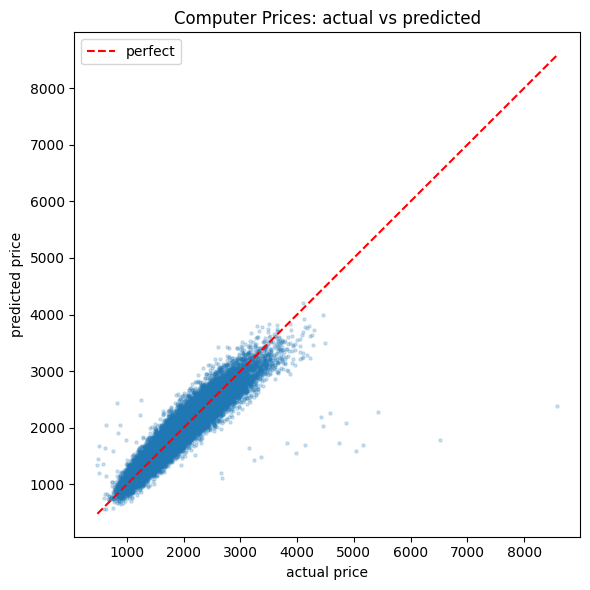

In [18]:
# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(yte, pred_pc, s=5, alpha=0.2)
lims = [yte.min(), yte.max()]
plt.plot(lims, lims, 'r--', label='perfect')
plt.xlabel('actual price'); plt.ylabel('predicted price')
plt.title('Computer Prices: actual vs predicted')
plt.legend(); plt.tight_layout(); plt.show()

## 6. 회귀 평가지표 정리

| 지표 | 의미 | 특징 | 단위 |
|------|------|------|------|
| **MAE** | 오차 절댓값의 평균 | 이상치에 덜 민감, 해석 쉬움 | 타깃과 같음 |
| **MSE** | 오차 제곱의 평균 | 큰 오차를 크게 벌함 | 타깃의 제곱 |
| **RMSE** | √MSE | MSE를 타깃 단위로 환산 | 타깃과 같음 |
| **R² (결정계수)** | 모델이 설명하는 분산 비율 | **1에 가까울수록 좋음**, 0이면 평균 예측 수준 | 없음(0~1) |

### 📝 시험 출제 포인트
- `mean_absolute_error`, `mean_squared_error`, `r2_score` 임포트 경로는 `sklearn.metrics`.
- **RMSE는 sklearn에 직접 함수가 없어** `np.sqrt(mean_squared_error(...))` 로 구한다.
  (최신 버전은 `mean_squared_error(y, p, squared=False)` 도 가능)

### ⚠️ 자주 하는 실수
- **R²가 음수** → 모델이 "그냥 평균"보다도 못하다는 뜻. 전처리/특성을 의심.
- MAE와 RMSE를 혼동 → RMSE는 큰 오차에 더 민감(제곱 때문).


## 7. 정리 & 핵심 체크리스트

### 전체 흐름 (외워두기)
```
데이터 로드 → EDA → 전처리(결측치·인코딩) → train/test 분리
→ 스케일링(train fit) → LinearRegression.fit → predict → 평가(MAE/RMSE/R²)
```

### 📝 시험 출제 포인트 (종합)
- `train_test_split(X, y, test_size=0.2, random_state=42)` 의 인자 의미.
- `scaler.fit_transform(train)` vs `scaler.transform(test)` 구분.
- `pd.get_dummies(..., drop_first=True)` 로 범주형 인코딩.
- `model.coef_` / `model.intercept_` 해석.

### ⚠️ 자주 하는 실수 (종합)
- 타깃을 특성에 포함 / test로 스케일러 fit / 범주형을 인코딩 없이 모델에 투입.
- 고카디널리티 식별자(`model` 등)를 그대로 원-핫 → 특성 수 폭발.

### 다음 학습
- **규제 회귀**: `Ridge`, `Lasso` (과적합 억제)
- **분류**: `LogisticRegression` (범주 예측)
- **트리 계열**: `RandomForestRegressor` (비선형 관계)
